# Energy/Oil Information Session Case Study

This notebook is the notebook-first acceptance gate for the information-session demo. It reads the same YAML config and cached artifacts as `run_experiment.py`, so figures and metrics stay aligned with the numerical experiment.


In [1]:
# ruff: noqa: E402, I001
from __future__ import annotations

import sys
from pathlib import Path


def find_case_study_dir() -> Path:
    """Find the playground package from common Jupyter working directories."""
    candidates = [Path.cwd(), *Path.cwd().parents]
    for candidate in candidates:
        direct = candidate / "config.py"
        nested = candidate / "playground" / "energy_case_study" / "config.py"
        if direct.exists():
            return candidate
        if nested.exists():
            return nested.parent
    raise FileNotFoundError("Could not locate playground/energy_case_study/config.py")


CASE_STUDY_DIR = find_case_study_dir()
if str(CASE_STUDY_DIR) not in sys.path:
    sys.path.insert(0, str(CASE_STUDY_DIR))

for module_name in ["config", "data", "experiment", "plots"]:
    sys.modules.pop(module_name, None)

from config import load_config
from experiment import artifact_paths, artifacts_exist, run_case_study
from plots import (
    best_model_id,
    load_news_annotations,
    load_story_frames,
    plot_backtest_eval_dashboard,
    plot_forecast_fan,
    plot_forecast_storyboard,
    plot_information_session_timeline,
)

config = load_config()
paths = artifact_paths(config)
config.display_label, paths.output_dir

('Energy/Oil Information Session Case Study',
 PosixPath('/Users/ethanjackson/agentic-forecasting/playground/energy_case_study/artifacts'))

## Run Or Load Artifacts

The experiment compares three sklearn-backed groups aligned with `configs/case_study.yaml`: a univariate ridge baseline on price levels, a multivariate Huber model on **price-change targets** with engineered macro features (no futures), and a matched **ridge** model with futures-proxy spreads (basis, Brent–WTI, crack proxy). Default horizon is **20 business days**. The live presentation should usually load cached artifacts rather than recompute.

In [2]:
if not artifacts_exist(config) or config.artifacts.force_refresh_results:
    run_case_study(config)

model_selection_predictions, model_selection_metrics, q1_predictions, q1_metrics = load_story_frames(config)
model_selection_metrics

,window,model_id,model_label,n_predictions,mean_crps,mae,rmse,median_absolute_error,interval_coverage,mean_interval_width,alarm_rate
0,model_selection,univariate,Univariate ridge (level baseline),53,2.504761,3.528798,4.352320,3.531608,0.962264,16.609578,0.037736
1,model_selection,multivariate_no_futures,"Multivariate Huber engineered (macro, no futures)",53,2.978017,4.284751,5.154768,4.128816,0.943396,19.297646,0.056604
2,model_selection,multivariate_with_futures,Multivariate ridge engineered (futures basis &...,53,3.202568,4.507531,5.418395,4.594862,0.943396,18.972050,0.056604


## Five-year session timeline

One overview chart: realized **WTI spot** over roughly five years, **shaded regions** for the 2025 backtest scoring window and Q1 2026 eval, **dashed vertical lines** at the first rolling forecast origin in each window, model **point forecasts** (solid = backtest, dashed = Q1), and faint **90%** bands.


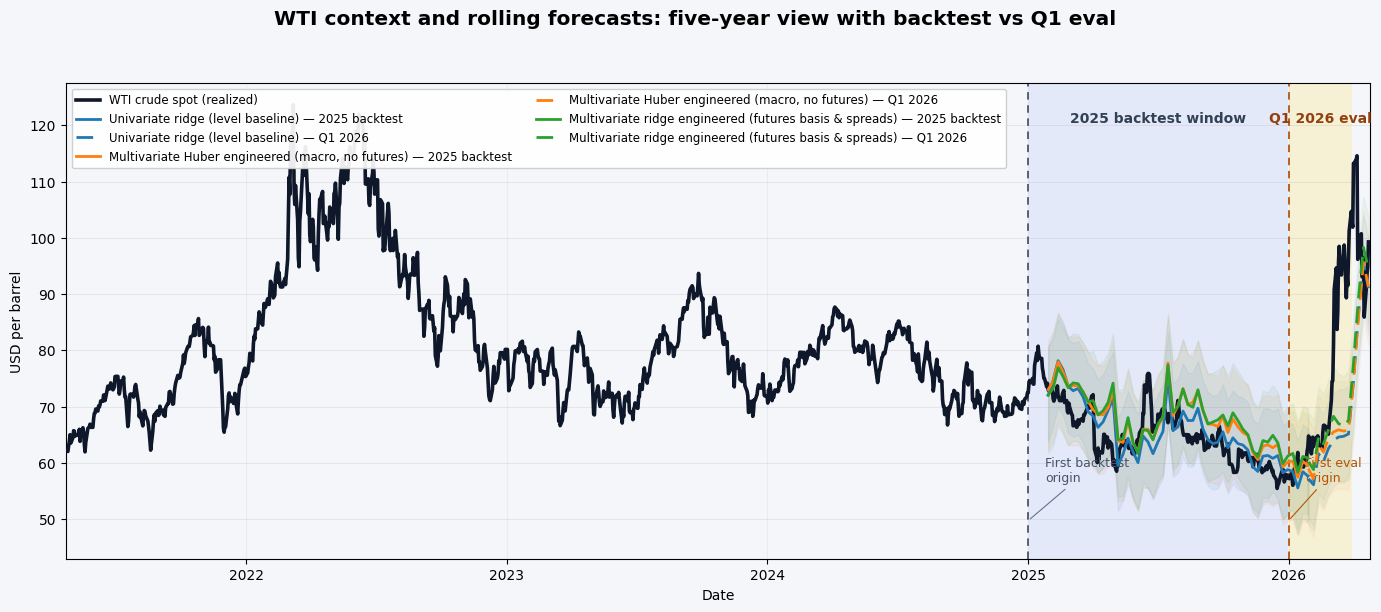

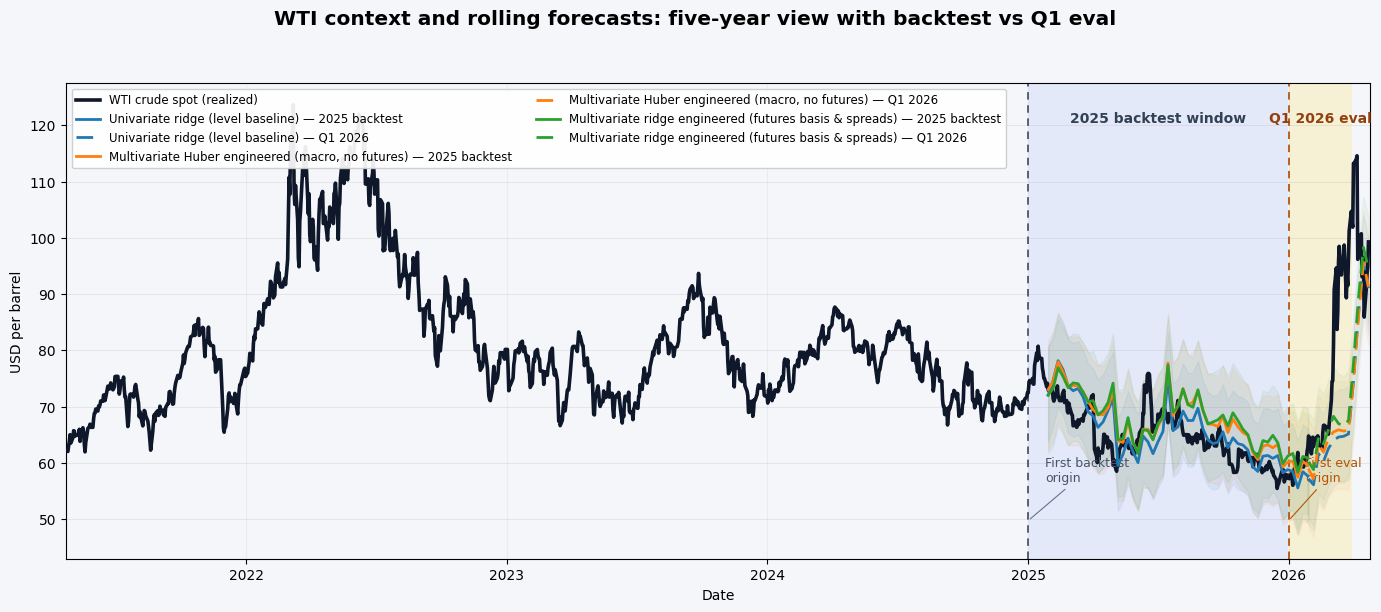

In [3]:
fig = plot_information_session_timeline(
    config,
    model_selection_predictions,
    q1_predictions,
    history_years=5.0,
)
fig


## Same view, zoomed to 2025–2026

Identical styling and shading as above, with the x-axis limited to **2025 onward** so the backtest and Q1 eval periods fill the frame.


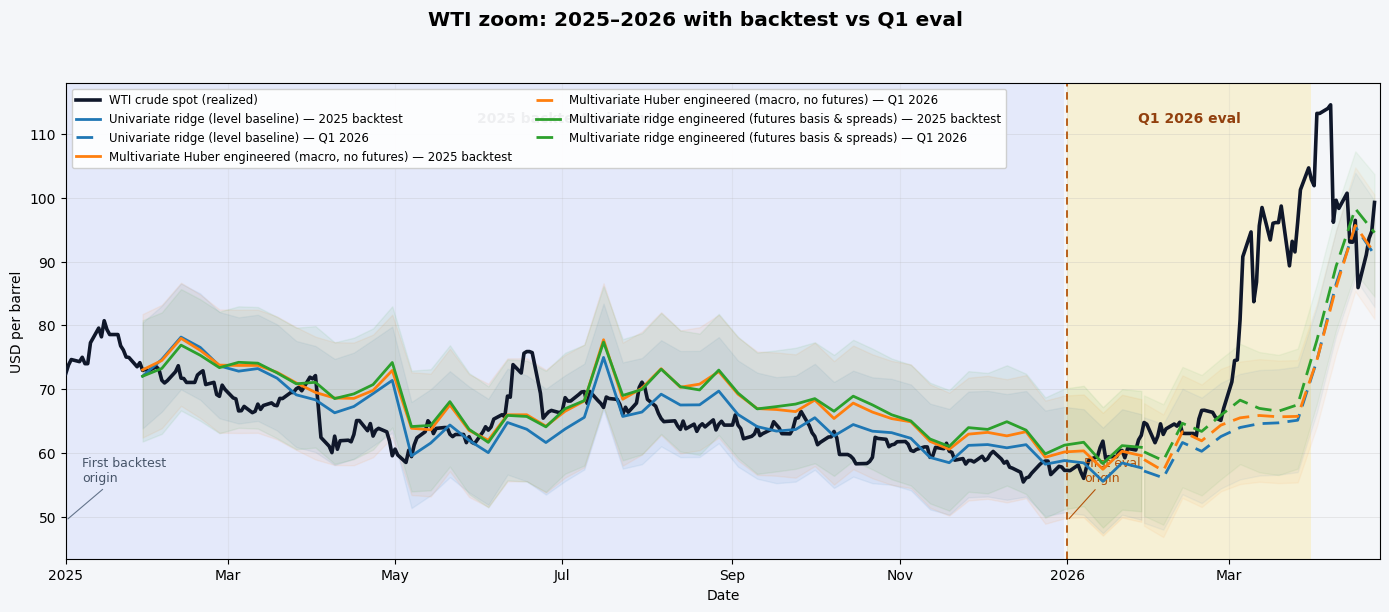

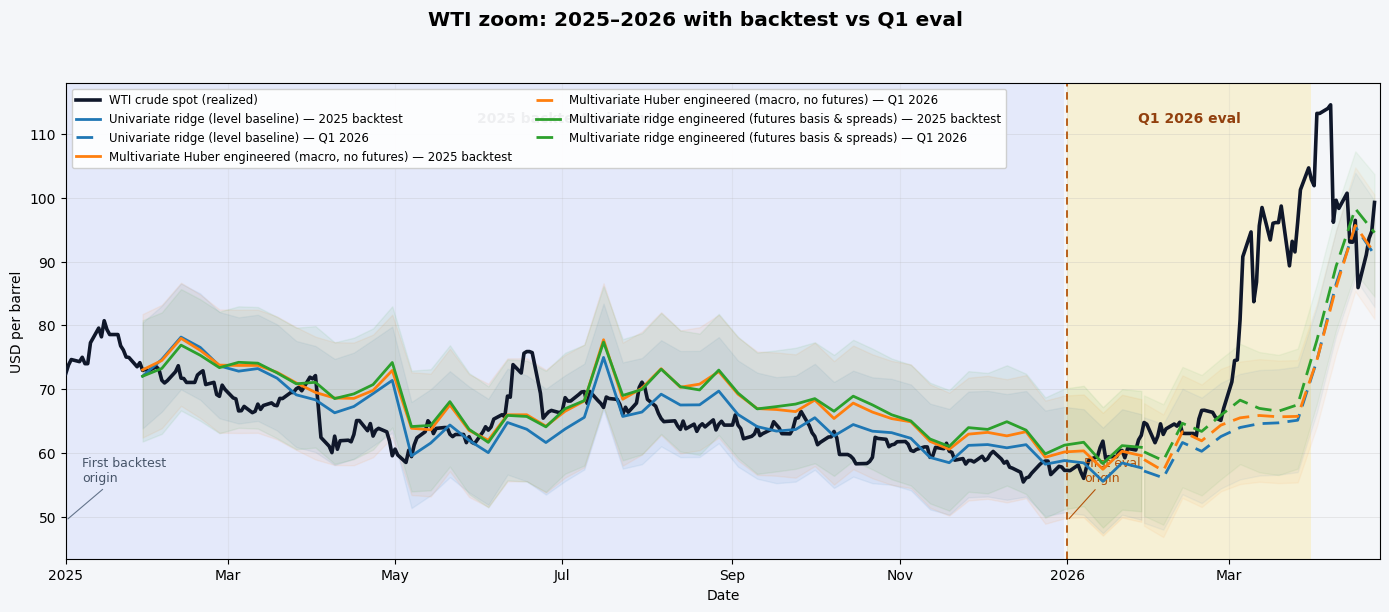

In [4]:
fig = plot_information_session_timeline(
    config,
    model_selection_predictions,
    q1_predictions,
    time_span="zoom_2025_2026",
)
fig


## Two-Plot Story View

The first plot compares backtest and current-period performance side by side: probabilistic score, point error, interval coverage, and alarm rate. The second plot overlays forecasts and realized prices for both periods so we can visually inspect whether the current period behaves differently from the model-selection year.

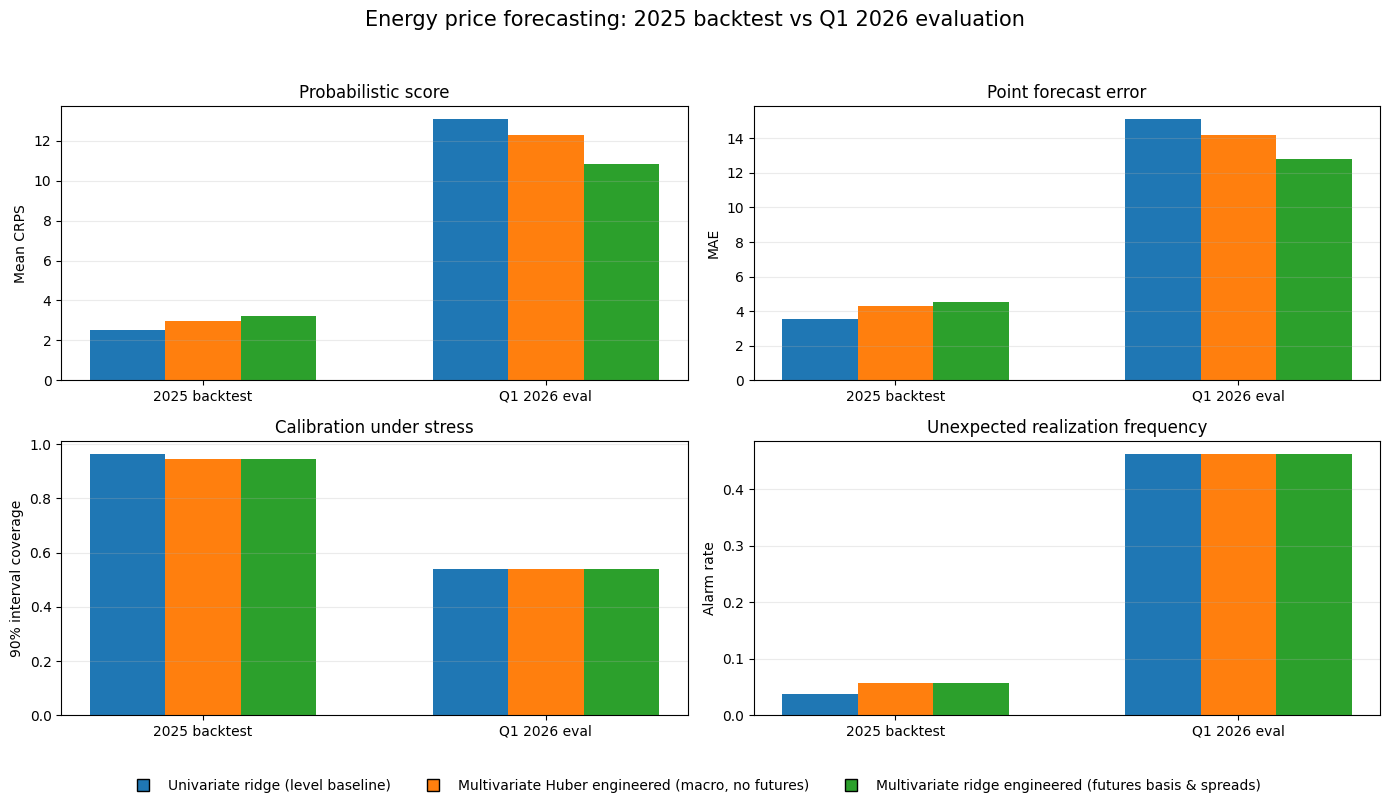

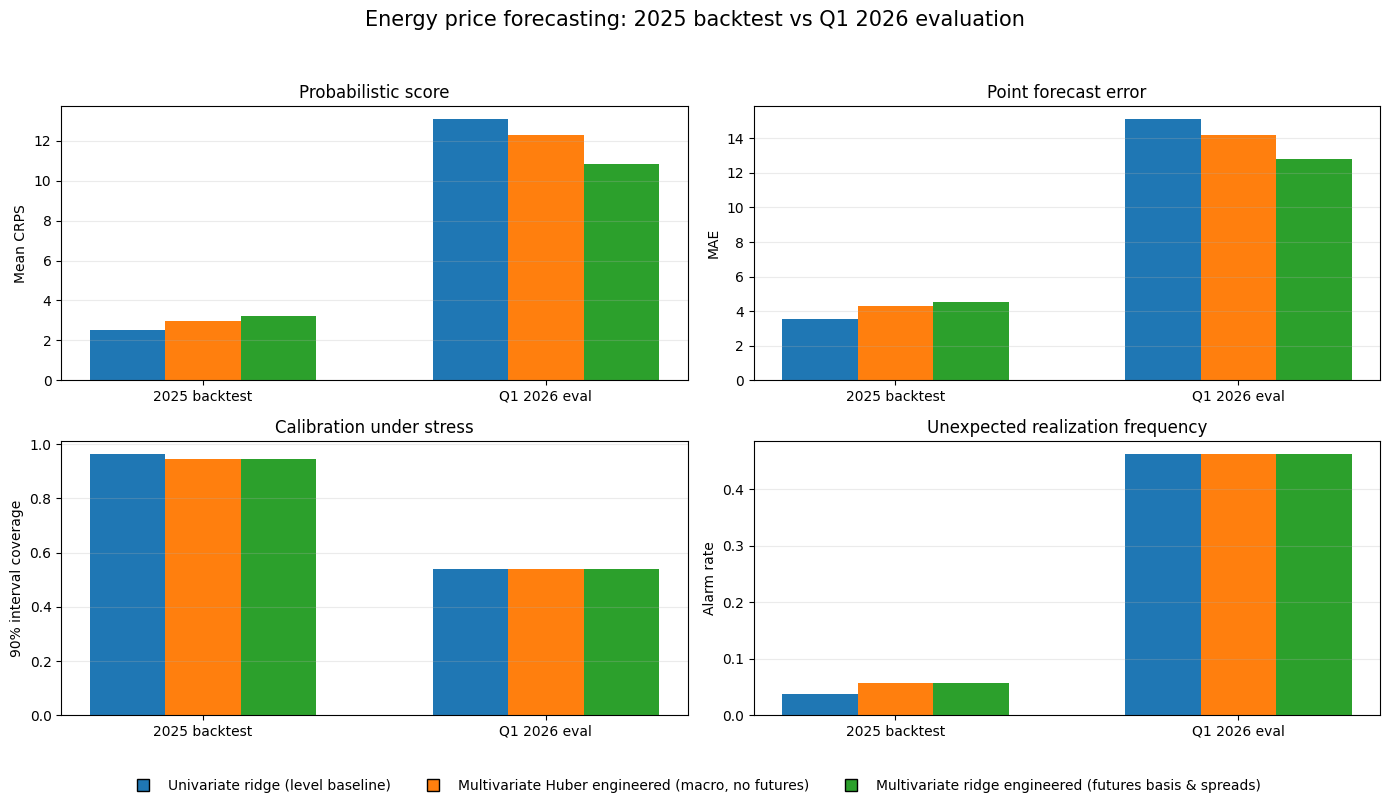

In [5]:
fig = plot_backtest_eval_dashboard(
    model_selection_metrics,
    q1_metrics,
    title="Energy price forecasting: 2025 backtest vs Q1 2026 evaluation",
)
fig

## Forecast Storyboard

This storyboard shows the same **default-horizon** (from `case_study.yaml`, currently 20 business days) resolution dates in the backtest and current-period windows. Black is realized WTI, colored lines are model point forecasts, translucent bands are 90% forecast intervals, and outlined dots mark alarm realizations outside the forecast interval.


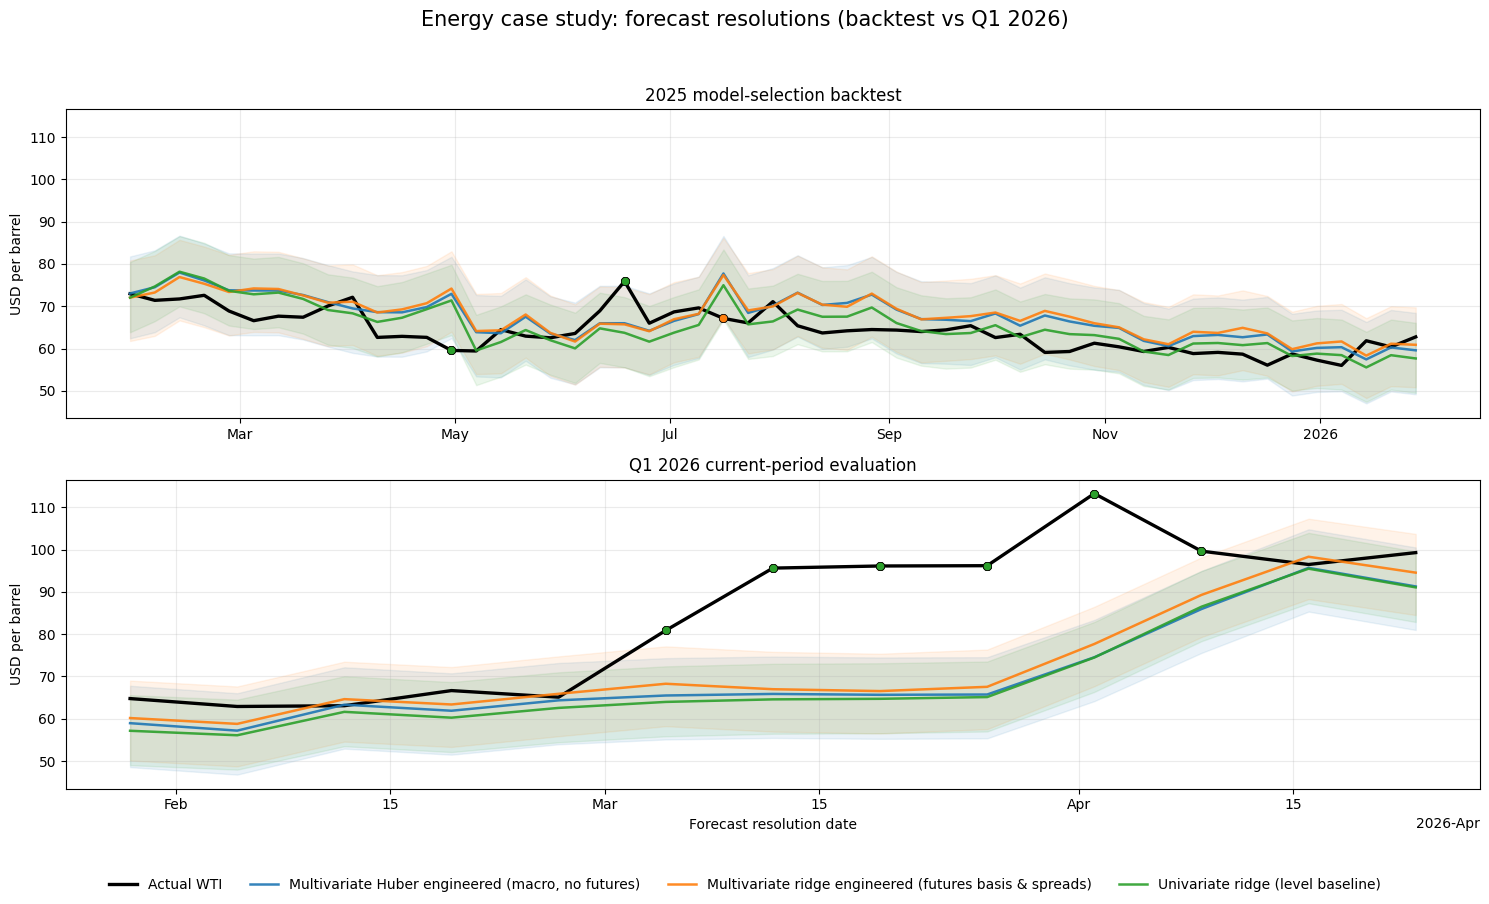

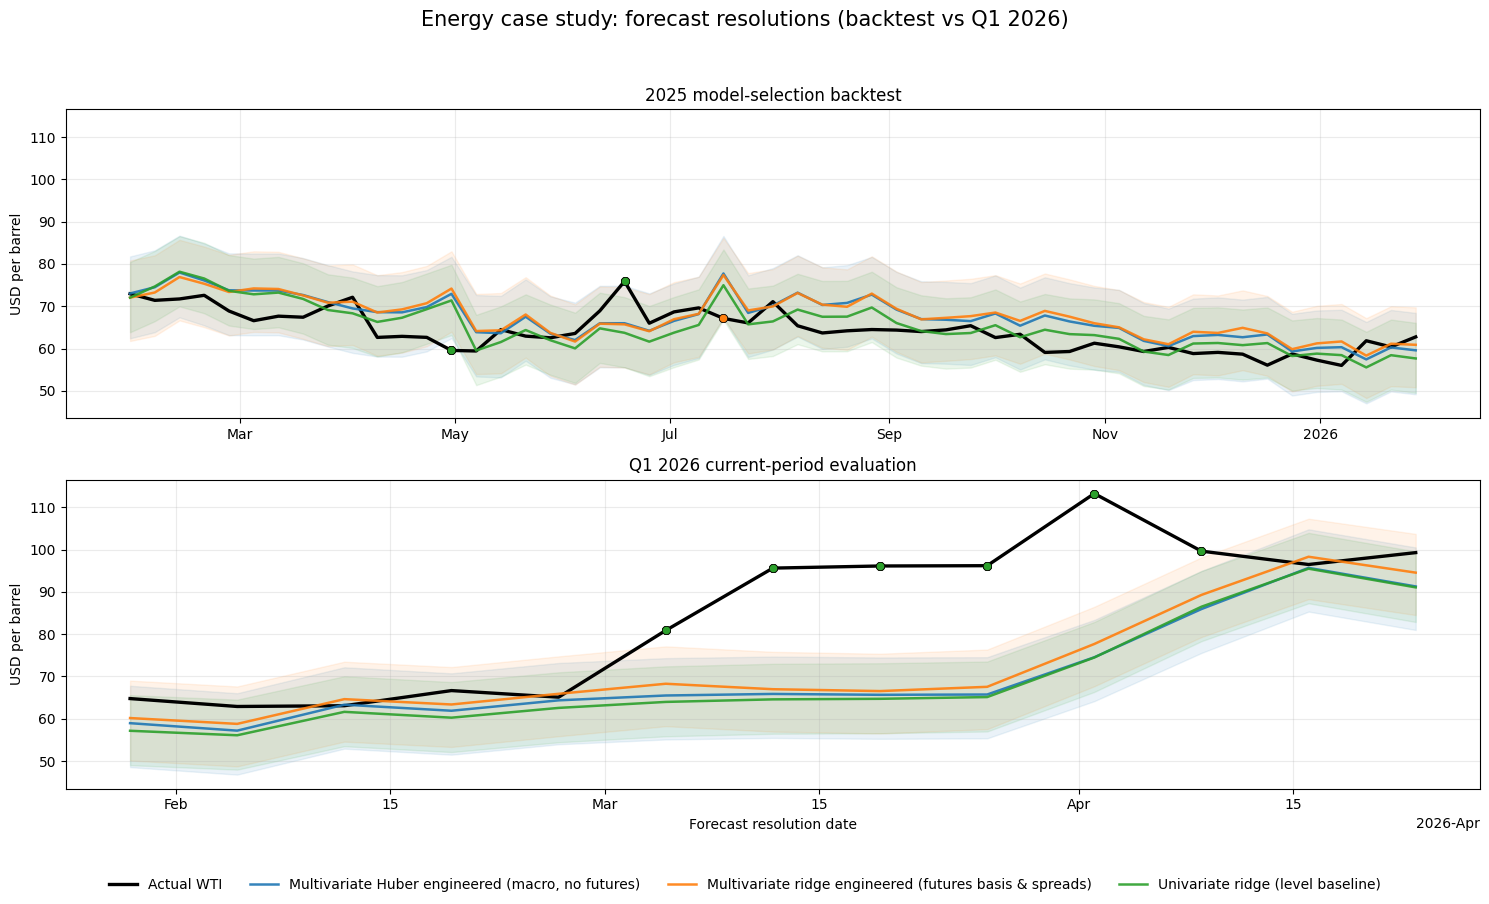

In [6]:
fig = plot_forecast_storyboard(
    model_selection_predictions,
    q1_predictions,
    title="Energy case study: forecast resolutions (backtest vs Q1 2026)",
)
fig

In [7]:
# Optional drilldowns
# The two figures above are intended as the presentation view. The remaining
# cells are optional diagnostics for detailed inspection after the main story is clear.

In [8]:
model_selection_metrics, q1_metrics

(            window                   model_id  \
 0  model_selection                 univariate   
 1  model_selection    multivariate_no_futures   
 2  model_selection  multivariate_with_futures   
 
                                          model_label  n_predictions  \
 0                  Univariate ridge (level baseline)             53   
 1  Multivariate Huber engineered (macro, no futures)             53   
 2  Multivariate ridge engineered (futures basis &...             53   
 
    mean_crps       mae      rmse  median_absolute_error  interval_coverage  \
 0   2.504761  3.528798  4.352320               3.531608           0.962264   
 1   2.978017  4.284751  5.154768               4.128816           0.943396   
 2   3.202568  4.507531  5.418395               4.594862           0.943396   
 
    mean_interval_width  alarm_rate  
 0            16.609578    0.037736  
 1            19.297646    0.056604  
 2            18.972050    0.056604  ,
            window                   

### Single-Model Forecast Fan

Use this when you want to inspect the selected model's interval shape in just the current-period window.

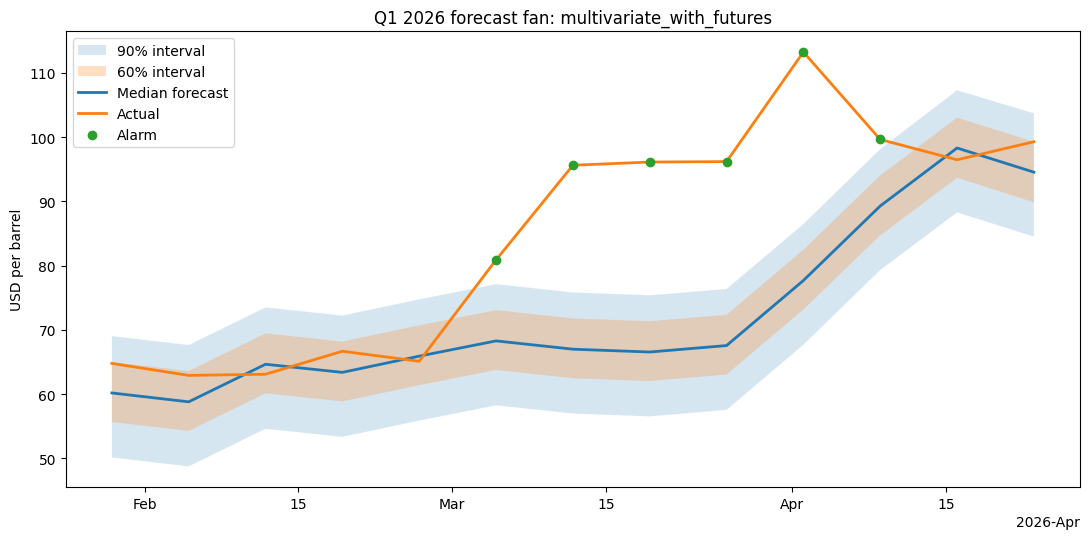

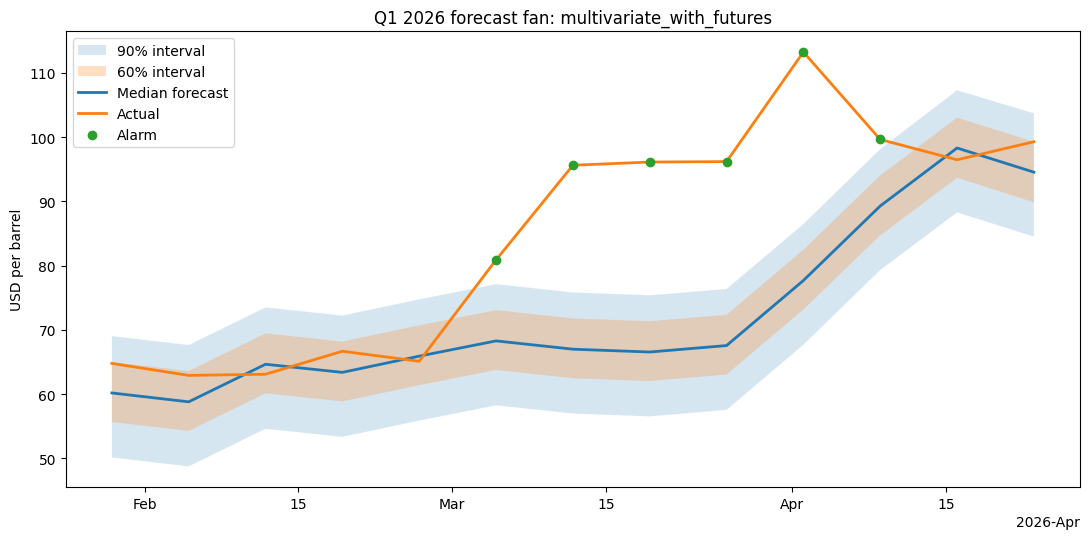

In [9]:
selected_model_id = best_model_id(q1_metrics)
annotations = load_news_annotations(Path("playground/news_search/outputs/news-grounding-q1-2026"))
fig = plot_forecast_fan(
    q1_predictions,
    model_id=selected_model_id,
    title=f"Q1 2026 forecast fan: {selected_model_id}",
    annotations=annotations,
)
fig